# Loan Process Analytics

Анализ процесса выдачи кредита на основе BPIC 2017.

Данные: событийный лог голландского банка. 31 509 заявок, 1 202 267 событий. Каждое событие — этап процесса с временной меткой, исполнителем и каналом.

Задача: найти узкие места в процессе — где заявки задерживаются, где клиенты отваливаются, какие этапы работают неэффективно.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pm4py
from pathlib import Path

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
%matplotlib inline

## Данные

Загружаю событийный лог в формате XES. Лог содержит три типа событий: A_* — действия на уровне заявки, W_* — workflow-задачи сотрудников, O_* — операции с офферами.

In [40]:
DATA_PATH = Path('../data/BPI Challenge 2017.xes')
print(f"Файл существует: {DATA_PATH.exists()}")
print(f"Размер: {DATA_PATH.stat().st_size / 1e6:.1f} MB")

log = pm4py.read_xes(str(DATA_PATH))
print(f"\nФорма: {log.shape}")
print(f"Колонки: {log.columns.tolist()}")
log.head()

Файл существует: True
Размер: 578.9 MB


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]


Форма: (1202267, 19)
Колонки: ['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']


,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
print(f"Всего событий:      {len(log):,}")
print(f"Уникальных заявок:  {log['case:concept:name'].nunique():,}")
print(f"Уникальных действий: {log['concept:name'].nunique()}")
print(f"\nВременной диапазон:")
print(f"  Начало: {log['time:timestamp'].min()}")
print(f"  Конец:  {log['time:timestamp'].max()}")
print(f"\nДействия (топ-20 по частоте):")
print(log['concept:name'].value_counts().head(20))

Всего событий:      1,202,267
Уникальных заявок:  31,509
Уникальных действий: 26

Временной диапазон:
  Начало: 2016-01-01 09:51:15.304000+00:00
  Конец:  2017-02-01 14:11:03.499000+00:00

Действия (топ-20 по частоте):
concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509
A_Concept                    31509
A_Accepted                   31509
A_Complete                   31362
O_Returned                   23305
A_Incomplete                 23055
O_Cancelled                  20898
A_Submitted                  20423
O_Accepted                   17228
A_Pending                    17228
A_Cancelled                  10431
Name: count, dtype: int64


In [38]:
df = log.copy()
df = df.rename(columns={
    'case:concept:name': 'case_id',
    'concept:name': 'activity',
    'time:timestamp': 'timestamp',
    'org:resource': 'resource',
    'case:LoanGoal': 'loan_goal',
    'case:ApplicationType': 'application_type',
    'case:RequestedAmount': 'requested_amount'
})

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

print(f"Строк: {len(df):,}")
print(f"Кейсов: {df['case_id'].nunique():,}")
print(f"Период: {df['timestamp'].min().date()} — {df['timestamp'].max().date()}")

Строк: 1,202,267
Кейсов: 31,509
Период: 2016-01-01 — 2017-02-01


## Длительность обработки заявок

Медиана — 19 дней, среднее — 22 дня, но разброс огромный: от нескольких часов до 286 дней. Треть заявок закрывается дольше 31 дня.

In [36]:
case_summary = df.groupby('case_id').agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    n_events=('activity', 'count'),
    loan_goal=('loan_goal', 'first'),
    app_type=('application_type', 'first'),
    requested_amount=('requested_amount', 'first')
).reset_index()

case_summary['duration_days'] = (case_summary['end'] - case_summary['start']).dt.total_seconds() / 86400

print(f"Всего заявок: {len(case_summary):,}")
print()
print(f"Длительность обработки заявки (дни):")
print(case_summary['duration_days'].describe().round(2))
print()
print(f"Распределение по типам заявок:")
print(case_summary['app_type'].value_counts())
print()
print(f"Распределение по целям кредита:")
print(case_summary['loan_goal'].value_counts().head(10))

Всего заявок: 31,509

Длительность обработки заявки (дни):
count    31509.00
mean        21.90
std         13.17
min          0.00
25%         11.32
50%         19.09
75%         31.50
max        286.07
Name: duration_days, dtype: float64

Распределение по типам заявок:
app_type
New credit     28120
Limit raise     3389
Name: count, dtype: int64

Распределение по целям кредита:
loan_goal
Car                       9328
Home improvement          7669
Existing loan takeover    5601
Other, see explanation    2985
Unknown                   2365
Not speficied             1065
Remaining debt home        842
Extra spending limit       625
Caravan / Camper           369
Motorcycle                 275
Name: count, dtype: int64


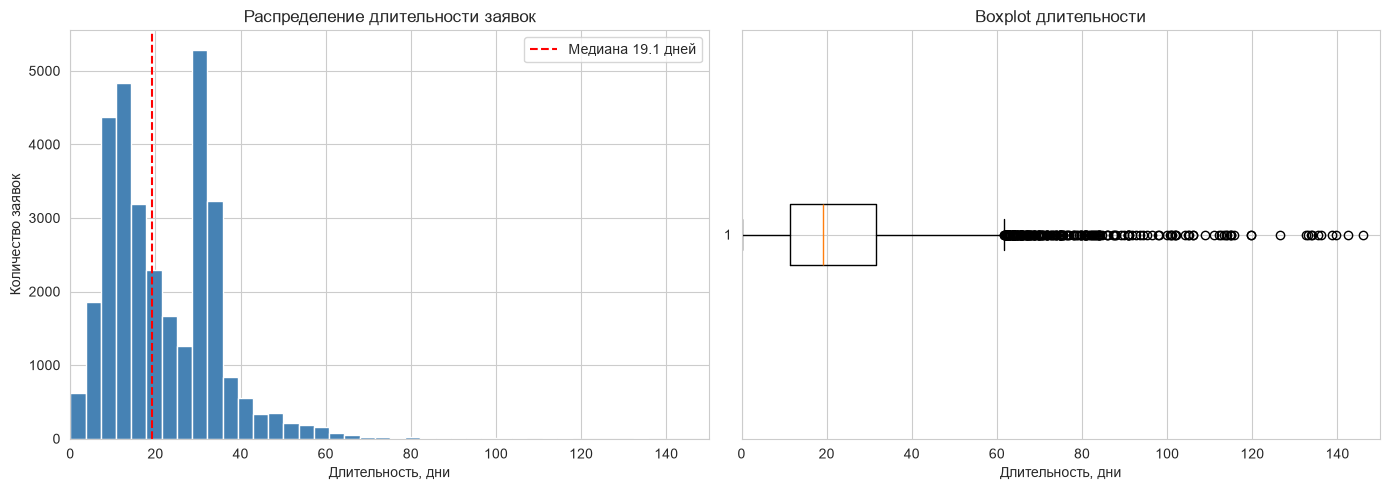

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(case_summary['duration_days'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Длительность, дни')
axes[0].set_ylabel('Количество заявок')
axes[0].set_title('Распределение длительности заявок')
axes[0].axvline(case_summary['duration_days'].median(), color='red', linestyle='--',
                label=f"Медиана {case_summary['duration_days'].median():.1f} дней")
axes[0].legend()
axes[0].set_xlim(0, 150)

axes[1].boxplot(case_summary['duration_days'], orientation='horizontal')
axes[1].set_xlabel('Длительность, дни')
axes[1].set_title('Boxplot длительности')
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.savefig('../assets/duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Воронка процесса

Традиционная воронка по финальным статусам не работает: в этом логе почти все заявки помечены как A_Complete. Реальные исходы видны через события с офферами: из 31 050 отправленных предложений клиенты приняли только 17 228.

Реальная воронка процесса:
           Этап  Заявок  Доля от старта, %
 Заявка создана   31509              100.0
   Оффер создан   31509              100.0
Оффер отправлен   31050               98.5
   Оффер принят   17228               54.7


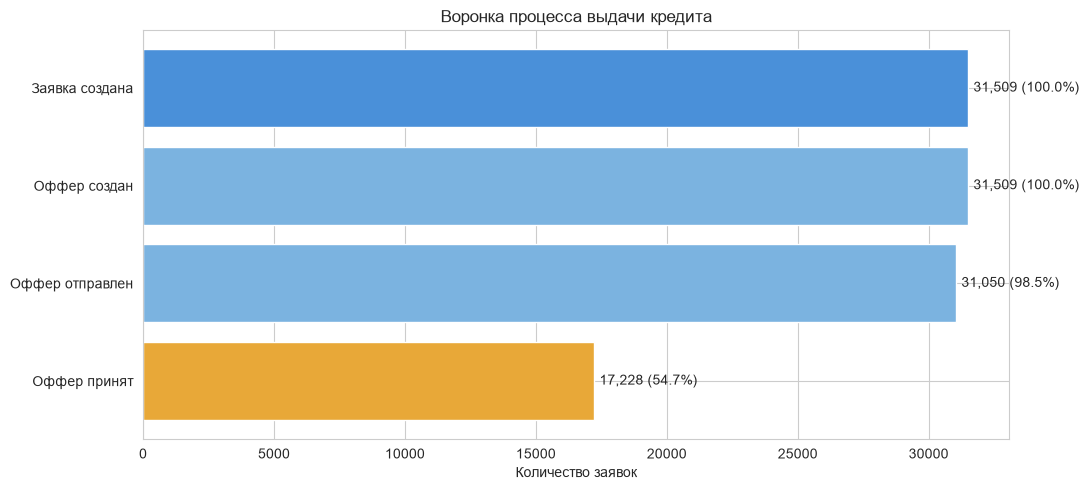

In [34]:
stages_order = [
    ('Заявка создана', 'A_Create Application'),
    ('Оффер создан', 'O_Created'),
    ('Оффер отправлен', 'O_Sent (mail and online)'),
    ('Оффер принят', 'O_Accepted'),
]

funnel = []
for label, activity in stages_order:
    n = df[df['activity'] == activity]['case_id'].nunique()
    funnel.append({'Этап': label, 'Заявок': n})

funnel_df = pd.DataFrame(funnel)
funnel_df['Доля от старта, %'] = (funnel_df['Заявок'] / funnel_df['Заявок'].iloc[0] * 100).round(1)

print("Реальная воронка процесса:")
print(funnel_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#4a90d9', '#7bb3e0', '#7bb3e0', '#e8a838']
bars = ax.barh(funnel_df['Этап'], funnel_df['Заявок'], color=colors)
ax.set_xlabel('Количество заявок')
ax.set_title('Воронка процесса выдачи кредита')
ax.invert_yaxis()
for bar, val, pct in zip(bars, funnel_df['Заявок'], funnel_df['Доля от старта, %']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct}%)', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../assets/funnel.png', dpi=150, bbox_inches='tight')
plt.show()

## Офферы и суммы

Проверяю, как соотносятся запрошенная клиентом сумма и предложенная банком.

In [33]:
offers = df.groupby('case_id').agg(
    requested_amount=('requested_amount', 'max'),
    offered_amount=('OfferedAmount', 'max'),
    credit_score=('CreditScore', 'max'),
    accepted=('Accepted', 'max'),
    selected=('Selected', 'max')
).reset_index()

offers = offers.dropna(subset=['offered_amount', 'requested_amount'])
offers = offers[offers['requested_amount'] > 0]
offers['ratio'] = offers['offered_amount'] / offers['requested_amount']

print(f"Заявок с обеими суммами: {len(offers):,}")
print()
print(f"Оффер меньше запрошенной суммы:  {(offers['ratio'] < 0.99).mean() * 100:.1f}%")
print(f"Оффер больше запрошенной суммы:  {(offers['ratio'] > 1.01).mean() * 100:.1f}%")
print(f"Оффер примерно равен запрошенной: {(offers['ratio'].between(0.99, 1.01)).mean() * 100:.1f}%")
print()
print(f"Средний CreditScore: {offers['credit_score'].mean():.0f}")
print(f"Доля Accepted == 1:  {(offers['accepted'] == 1).mean() * 100:.1f}%")
print(f"Доля Selected == 1:  {(offers['selected'] == 1).mean() * 100:.1f}%")

Заявок с обеими суммами: 28,429

Оффер меньше запрошенной суммы:  7.8%
Оффер больше запрошенной суммы:  12.7%
Оффер примерно равен запрошенной: 79.5%

Средний CreditScore: 433
Доля Accepted == 1:  72.7%
Доля Selected == 1:  68.3%


## Длительность переходов

Ключевые задержки: валидация документов и ожидание решения клиента.

In [11]:
def time_between(log_df, act_from, act_to):
    a = log_df[log_df['activity'] == act_from].groupby('case_id')['timestamp'].min()
    b = log_df[log_df['activity'] == act_to].groupby('case_id')['timestamp'].min()
    delta = (b - a).dt.total_seconds() / 86400
    return delta.dropna()

transitions = [
    ('A_Submitted', 'A_Validating', 'Подача → Валидация'),
    ('A_Validating', 'A_Pending', 'Валидация → Ожидание решения'),
    ('O_Sent (mail and online)', 'O_Accepted', 'Отправка оффера → Принятие'),
    ('O_Sent (mail and online)', 'O_Cancelled', 'Отправка оффера → Отмена'),
]

rows = []
for act_from, act_to, label in transitions:
    d = time_between(df, act_from, act_to)
    if len(d) > 0:
        rows.append({
            'Переход': label,
            'Заявок': len(d),
            'Медиана, дней': round(d.median(), 2),
            'Среднее, дней': round(d.mean(), 2),
            '90-й перцентиль': round(d.quantile(0.9), 2),
        })

transition_df = pd.DataFrame(rows)
print("Длительность переходов между этапами:")
print(transition_df.to_string(index=False))

Длительность переходов между этапами:
                     Переход  Заявок  Медиана, дней  Среднее, дней  90-й перцентиль
          Подача → Валидация   13333           9.93          12.37            22.11
Валидация → Ожидание решения   17228           4.96           6.99            16.75
  Отправка оффера → Принятие   17038          13.78          16.78            30.81
    Отправка оффера → Отмена   15446          30.56          24.14            33.87


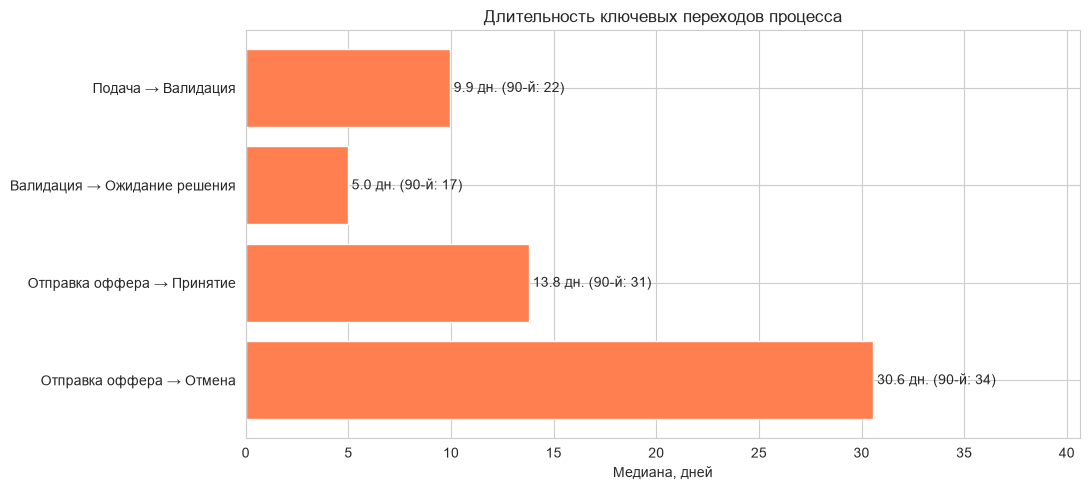

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(transition_df['Переход'], transition_df['Медиана, дней'], color='coral')
ax.set_xlabel('Медиана, дней')
ax.set_title('Длительность ключевых переходов процесса')
ax.invert_yaxis()
for bar, val, q90 in zip(bars, transition_df['Медиана, дней'], transition_df['90-й перцентиль']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} дн. (90-й: {q90:.0f})', va='center', fontsize=10)
plt.xlim(0, transition_df['90-й перцентиль'].max() * 1.2)
plt.tight_layout()
plt.savefig('../assets/transitions.png', dpi=150, bbox_inches='tight')
plt.show()

## Схема процесса

Схемы AS-IS и TO-BE построены в BPMN-нотации с двумя дорожками: Клиент и Банк. AS-IS описывает текущий процесс, TO-BE — предложенные улучшения.

![AS-IS](../assets/as-is.png)

![TO-BE](../assets/to-be.png)

В TO-BE три ключевых изменения: автоматическая валидация документов вместо ручной, follow-up напоминания клиенту на 7-й, 14-й и 21-й день, сокращение срока автоотмены с 30 до 21 дня.

## Результаты и выводы

**Длительность.** Медиана обработки заявки — 19 дней, среднее — 22 дня, максимум — 286 дней. Треть заявок закрывается дольше 31 дня.

**Воронка.** Оффер отправлен 31 050 заявкам, принят — 17 228 (54.7%). Остальные 45% отменяются автоматически через 30 дней без ответа.

**Узкие места:**
1. Валидация документов — медиана 9.9 дней
2. Ожидание решения клиента — медиана 13.8 дней
3. Автоматическая отмена оффера через 30 дней без ответа

**Рекомендации:**
- Автоматизировать первичную валидацию документов
- Добавить follow-up напоминания клиентам на 7-й, 14-й и 21-й день после отправки оффера
- Сократить срок автоотмены с 30 до 21 дня для неактивных заявок